In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
import pickle


from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression as lr
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.ensemble import GradientBoostingClassifier as gb
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.metrics import roc_auc_score
from sklearn.base import clone


In [2]:
file_path = "UDS.csv"

read_func = pd.read_excel if file_path.lower().endswith("xlsx") else pd.read_csv
df = read_func(file_path, low_memory=False)

print(f"✅ Dataset carregado com sucesso!")
print(f"Formato: {df.shape[0]} linhas × {df.shape[1]} colunas")

display(df.head())
print("\nColunas disponíveis:")
print(list(df.columns))


✅ Dataset carregado com sucesso!
Formato: 205908 linhas × 1024 colunas


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,...,NPATGAM1,NPATGAM2,NPATGAM3,NPATGAM4,NPATGAM5,NPATGFRN,NPATGFR1,NPATGFR2,NPATGFR3,NPATGFR4
0,NACC002909,186,I,3.0,12,28,2022,1,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
1,NACC002909,186,F,3.0,1,23,2024,2,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
2,NACC002909,186,F,3.0,3,5,2025,3,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
3,NACC003142,186,I,3.0,2,11,2025,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
4,NACC003487,186,I,3.0,11,15,2023,1,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4



Colunas disponíveis:
['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST', 'NACCDAYS', 'NACCFDYS', 'NACCCORE', 'NACCREAS', 'NACCREFR', 'BIRTHMO', 'BIRTHYR', 'SEX', 'HISPANIC', 'HISPOR', 'HISPORX', 'RACE', 'RACEX', 'RACESEC', 'RACESECX', 'RACETER', 'RACETERX', 'PRIMLANG', 'PRIMLANX', 'EDUC', 'MARISTAT', 'NACCLIVS', 'INDEPEND', 'RESIDENC', 'HANDED', 'INBIRMO', 'INBIRYR', 'INSEX', 'NEWINF', 'INHISP', 'INHISPOR', 'INHISPOX', 'NACCNINR', 'INRACE', 'INRACEX', 'INRASEC', 'INRASECX', 'INRATER', 'INRATERX', 'INEDUC', 'INRELTO', 'INRELTOX', 'INKNOWN', 'INLIVWTH', 'INVISITS', 'INCALLS', 'INRELY', 'NACCFAM', 'NACCMOM', 'NACCDAD', 'NACCAM', 'NACCAMX', 'NACCAMS', 'NACCAMSX', 'NACCFM', 'NACCFMX', 'NACCFMS', 'NACCFMSX', 'NACCOM', 'NACCOMX', 'NACCOMS', 'NACCOMSX', 'NACCFADM', 'NACCFFTD', 'ANYMEDS', 'DRUG1', 'DRUG2', 'DRUG3', 'DRUG4', 'DRUG5', 'DRUG6', 'DRUG7', 'DRUG8', 'DRUG9', 'DRUG10', 'DRUG11', 'DRUG12', 'DRUG13', 'DRUG14', 'DRUG15', 'DRUG1

In [3]:
# ============================================
# CONTAGEM DE PACIENTES COM PARKINSON NO DATASET
# ============================================

parkinson_cols = ['PD', 'NACCPDMD']   # colunas que indicam Parkinson
valid_cols = [col for col in parkinson_cols if col in df.columns]

if not valid_cols:
    print("⚠ Nenhuma coluna de Parkinson encontrada no dataframe!")
else:
    print(f"🔍 Colunas utilizadas para identificar Parkinson: {valid_cols}")

    # Cria máscara combinada de Parkinson
    parkinson_mask = np.zeros(len(df), dtype=bool)
    for col in valid_cols:
        parkinson_mask |= (df[col] == 1)

    n_pacientes_parkinson = df.loc[parkinson_mask, 'NACCID'].nunique()

    print(f"\n🧠 Total de pacientes COM Parkinson no dataset: {n_pacientes_parkinson:,}")


🔍 Colunas utilizadas para identificar Parkinson: ['PD', 'NACCPDMD']

🧠 Total de pacientes COM Parkinson no dataset: 4,397


### PRE PROCESSING

In [4]:
vars_diagnostico = [
    "NACCPDMD", "PD", "PARKSIGN", "PARKGAIT", "PARK",
    "DATSCAN", "NACCLBDS", "LBDEVAL", "NACCLBDE", "NACCLBDP",
    "PDOTHR", "PDOTHRYR"
]

vars_motor = [
    "BRADYKIN", "BRADYKIX", "POSTURE", "POSTUREX", "GAIT", "GAITX",
    "POSSTAB", "POSSTABX", "PDNORMAL"
]

vars_rigidez = [
    "RIGDNECK", "RIGDNEX", "RIGDUPRT", "RIGDUPRX",
    "RIGDUPLF", "RIGDUPLX", "RIGDLORT", "RIGDLORX",
    "RIGDLOLF", "RIGDLOLX"
]

vars_tremor_mov = [
    "TRESTFAC", "TRESTFAX", "TRESTRHD", "TRESTRHX",
    "TRESTLHD", "TRESTLHX", "TRESTRFT", "TRESTRFX",
    "TRESTLFT", "TRESTLFX", "TRACTRHD", "TRACTRHX",
    "TRACTLHD", "TRACTLHX", "TAPSRT", "TAPSRTX",
    "TAPSLF", "TAPSLFX", "HANDMOVR", "HANDMVRX",
    "HANDMOVL", "HANDMVLX", "HANDALTR", "HANDATRX",
    "HANDALTL", "HANDATLX", "LEGRT", "LEGRTX",
    "LEGLF", "LEGLFX", "ARISING", "ARISINGX"
]

vars_fala_expressao = [
    "SPEECH", "SPEECHX", "FACEXP", "FACEXPX"
]

vars_familia = [
    "MOMOPARK", "PARKAGE"
]

vars_all = (
    vars_diagnostico
    + vars_motor
    + vars_rigidez
    + vars_tremor_mov
    + vars_fala_expressao
    + vars_familia
)

present = [v for v in vars_all if v in df.columns]
missing = [v for v in vars_all if v not in df.columns]

print(f"Total de variáveis listadas: {len(vars_all)}")
print(f"Encontradas no dataset: {len(present)}")
print(f"Ausentes: {len(missing)}")

if missing:
    print("\nVariáveis não encontradas (ausentes no seu arquivo):")
    print(missing)

summary = (
    df[present]
    .notna()
    .mean()
    .reset_index()
    .rename(columns={"index": "Variável", 0: "% Preenchido"})
)


type_map = df[present].dtypes

summary['Tipo'] = summary['Variável'].map(type_map)


summary["% Preenchido"] = (summary["% Preenchido"] * 100).round(2)

summary = summary[['Variável', 'Tipo', '% Preenchido']]

summary = summary.sort_values("% Preenchido", ascending=False)

print("\n📋 Percentual de preenchimento e Tipos de Dados:")
display(summary)


def cat_summary(cat_name, vars_list):
    found = [v for v in vars_list if v in present]
    print(f"\n📂 {cat_name} — {len(found)} variáveis encontradas:")
    print(found if found else "Nenhuma encontrada.")

cat_summary("Diagnóstico (Parkinson / Lewy)", vars_diagnostico)
cat_summary("Exame motor", vars_motor)
cat_summary("Rigidez", vars_rigidez)
cat_summary("Tremor e movimentos", vars_tremor_mov)
cat_summary("Fala e expressão facial", vars_fala_expressao)
cat_summary("Histórico familiar", vars_familia)

Total de variáveis listadas: 69
Encontradas no dataset: 69
Ausentes: 0

📋 Percentual de preenchimento e Tipos de Dados:


,Variável,Tipo,% Preenchido
0,NACCPDMD,int64,100.00
25,RIGDUPLF,int64,100.00
29,RIGDLOLF,int64,100.00
31,TRESTFAC,int64,100.00
33,TRESTRHD,int64,100.00
...,...,...,...
38,TRESTRFX,object,0.03
36,TRESTLHX,object,0.03
66,FACEXPX,object,0.03
34,TRESTRHX,object,0.03



📂 Diagnóstico (Parkinson / Lewy) — 12 variáveis encontradas:
['NACCPDMD', 'PD', 'PARKSIGN', 'PARKGAIT', 'PARK', 'DATSCAN', 'NACCLBDS', 'LBDEVAL', 'NACCLBDE', 'NACCLBDP', 'PDOTHR', 'PDOTHRYR']

📂 Exame motor — 9 variáveis encontradas:
['BRADYKIN', 'BRADYKIX', 'POSTURE', 'POSTUREX', 'GAIT', 'GAITX', 'POSSTAB', 'POSSTABX', 'PDNORMAL']

📂 Rigidez — 10 variáveis encontradas:
['RIGDNECK', 'RIGDNEX', 'RIGDUPRT', 'RIGDUPRX', 'RIGDUPLF', 'RIGDUPLX', 'RIGDLORT', 'RIGDLORX', 'RIGDLOLF', 'RIGDLOLX']

📂 Tremor e movimentos — 32 variáveis encontradas:
['TRESTFAC', 'TRESTFAX', 'TRESTRHD', 'TRESTRHX', 'TRESTLHD', 'TRESTLHX', 'TRESTRFT', 'TRESTRFX', 'TRESTLFT', 'TRESTLFX', 'TRACTRHD', 'TRACTRHX', 'TRACTLHD', 'TRACTLHX', 'TAPSRT', 'TAPSRTX', 'TAPSLF', 'TAPSLFX', 'HANDMOVR', 'HANDMVRX', 'HANDMOVL', 'HANDMVLX', 'HANDALTR', 'HANDATRX', 'HANDALTL', 'HANDATLX', 'LEGRT', 'LEGRTX', 'LEGLF', 'LEGLFX', 'ARISING', 'ARISINGX']

📂 Fala e expressão facial — 4 variáveis encontradas:
['SPEECH', 'SPEECHX', 'FACEXP', '

In [5]:
threshold = 0.8  
vars_good = (
    summary.loc[summary["% Preenchido"] >= threshold * 100, "Variável"]
    .tolist()
)

df_park = df[vars_good].copy()

print(f"✅ {len(vars_good)} variáveis mantidas (preenchimento ≥ 80%)")

✅ 42 variáveis mantidas (preenchimento ≥ 80%)


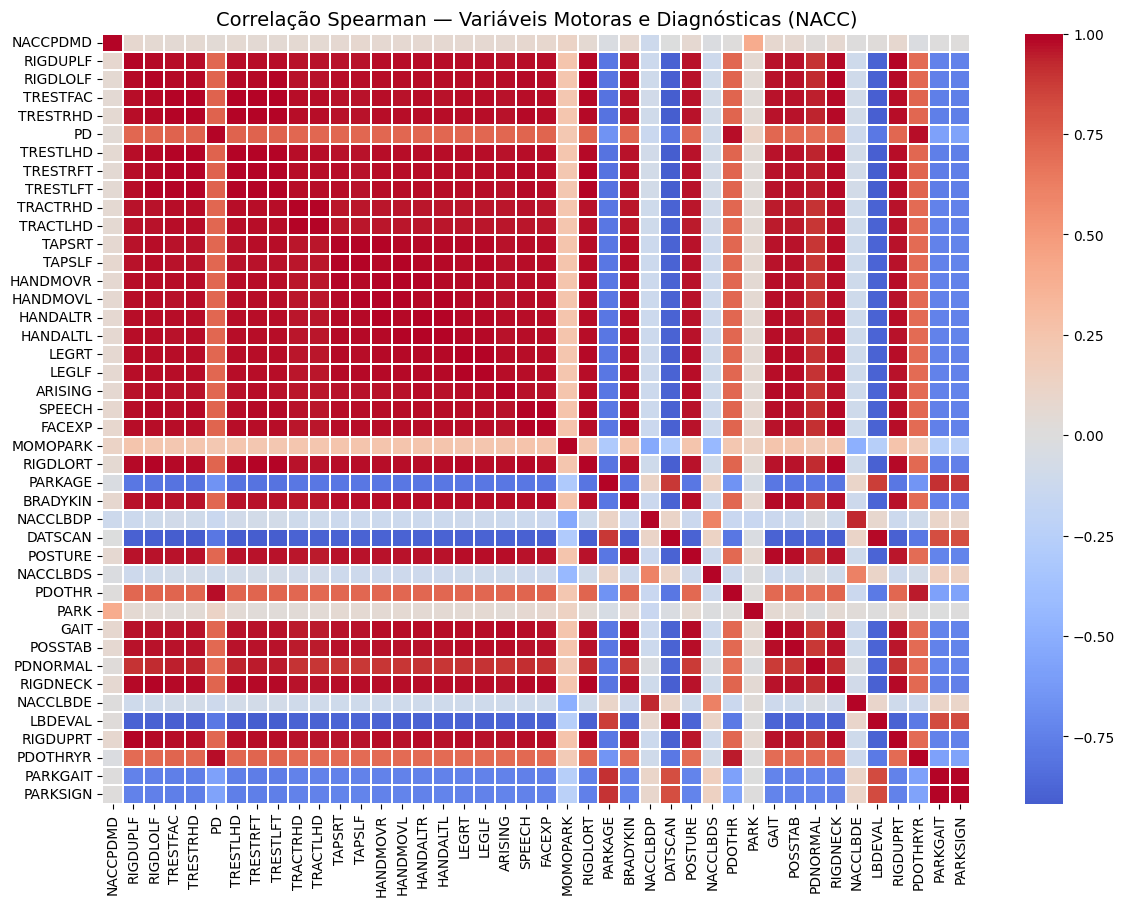

Lista de variáveis com bom preenchimento salva em 'vars_park_lewy_usable.txt'.


In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_park.corr(method="spearman"),
    cmap="coolwarm", center=0, linewidths=0.3
)
plt.title("Correlação Spearman — Variáveis Motoras e Diagnósticas (NACC)", fontsize=14)
plt.show()


with open("vars_park_lewy_usable.txt", "w") as f:
    for col in vars_good:
        f.write(col + "\n")
print("Lista de variáveis com bom preenchimento salva em 'vars_park_lewy_usable.txt'.")

In [7]:
tabela_nacc = (
        df["DEMENTED"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável DEMENTED:")
display(tabela_nacc)



Distribuição da variável DEMENTED:


,Código Diagnóstico,Frequência,%
0,0,146336,71.07
1,1,59572,28.93


In [8]:

tabela_nacc = (
        df["NACCUDSD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável NACCUDSD:")
display(tabela_nacc)


Distribuição da variável NACCUDSD:


,Código Diagnóstico,Frequência,%
0,1,100992,49.05
1,2,9090,4.41
2,3,36254,17.61
3,4,59572,28.93


🧠 Pacientes com Parkinson (todas as visitas): 4,397
📌 Pacientes COM Parkinson na baseline: 2,593

📊 Demência incidente:
incident_dementia
0    1958
1     635
Name: count, dtype: int64

🎯 Total de features encontradas no baseline: 42

🧩 Dataset final: 2593 pacientes × 42 variáveis
✅ Após remoção de NAs: 2593 pacientes | 42 variáveis

📊 Distribuição final da variável alvo:
incident_dementia
0    1958
1     635
Name: count, dtype: int64


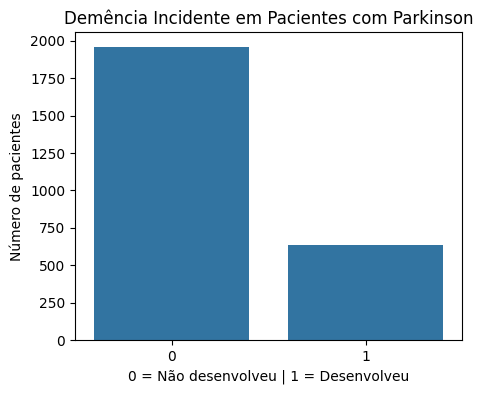

In [9]:
# =======================================================
# 1) Selecionar pacientes COM Parkinson
# =======================================================

parkinson_cols = ["PD", "NACCPDMD"]
parkinson_found = [c for c in parkinson_cols if c in df.columns]

if not parkinson_found:
    raise ValueError("Nenhuma variável de Parkinson encontrada.")

mask_park = np.zeros(len(df), dtype=bool)
for c in parkinson_found:
    mask_park |= (df[c] == 1)

df_park = df.loc[mask_park].copy()
print(f"🧠 Pacientes com Parkinson (todas as visitas): {df_park['NACCID'].nunique():,}")

# =======================================================
# 2) Filtrar BASELINE (1ª visita do paciente)
# =======================================================

baseline = df_park[df_park["NACCVNUM"] == 1].copy()
print(f"📌 Pacientes COM Parkinson na baseline: {baseline['NACCID'].nunique():,}")

# =======================================================
# 3) Identificar demência incidente (após baseline)
# =======================================================

followup = df_park[(df_park["NACCVNUM"] > 1) & (df_park["DEMENTED"] == 1)]
incident_ids = followup["NACCID"].unique()

baseline["incident_dementia"] = baseline["NACCID"].isin(incident_ids).astype(int)

print("\n📊 Demência incidente:")
print(baseline["incident_dementia"].value_counts())

# =======================================================
# 4) Selecionar apenas as FEATURES desejadas
# =======================================================

with open("vars_park_lewy_usable.txt", "r") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

feature_cols = [c for c in feature_cols if c in baseline.columns]

print(f"\n🎯 Total de features encontradas no baseline: {len(feature_cols)}")

# =======================================================
# 5) Montar X e y (1 linha por paciente)
# =======================================================

X = baseline[feature_cols].copy()
y = baseline["incident_dementia"].copy()

print(f"\n🧩 Dataset final: {X.shape[0]} pacientes × {X.shape[1]} variáveis")

# =======================================================
# 6) Remover pacientes com NA
# =======================================================

mask_valid = X.notna().all(axis=1)
X = X.loc[mask_valid]
y = y.loc[mask_valid]

print(f"✅ Após remoção de NAs: {X.shape[0]} pacientes | {X.shape[1]} variáveis")

# =======================================================
# 7) Distribuição final
# =======================================================

print("\n📊 Distribuição final da variável alvo:")
print(y.value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Demência Incidente em Pacientes com Parkinson")
plt.xlabel("0 = Não desenvolveu | 1 = Desenvolveu")
plt.ylabel("Número de pacientes")
plt.show()


In [10]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Validação cruzada configurada: {n_splits} folds (Stratified)")

unique, counts = np.unique(y, return_counts=True)
print("\n📈 Distribuição da variável alvo:")
for label, count in zip(unique, counts):
    pct = count / sum(counts) * 100
    print(f"Classe {label}: {count} amostras ({pct:.1f}%)")

Formato de X: (2593, 42)
Formato de y: (2593,)
Validação cruzada configurada: 5 folds (Stratified)

📈 Distribuição da variável alvo:
Classe 0: 1958 amostras (75.5%)
Classe 1: 635 amostras (24.5%)


In [11]:

def impute(raw_data):
   
    data = raw_data.copy()
    for var_ind in range(data.shape[1]):
        variable = data[:, var_ind]
        if np.sum(pd.isnull(variable)) > 0:
            sample = variable[~pd.isnull(variable)]
            if len(sample) > 0:
                replace_vals = np.random.choice(sample, np.sum(pd.isnull(variable)), replace=True)
                variable[pd.isnull(variable)] = replace_vals
                data[:, var_ind] = variable
    return data

print("\n🧩 Aplicando imputação de valores faltantes (estilo James)...")
X_array = X.values  
X_imputed = impute(X_array)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

X = X_imputed_df

print(f"✅ Imputação concluída — Shape: {X.shape} | NaN restantes: {np.isnan(X).sum().sum()}")



🧩 Aplicando imputação de valores faltantes (estilo James)...
✅ Imputação concluída — Shape: (2593, 42) | NaN restantes: 0


In [12]:
#X_final = preprocessing.scale(X)
#print("Dados escalonados com preprocessing.scale")

#y_array = y.to_numpy()

#print(f"Dataset final pronto: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")
#print(f"Distribuição da variável alvo: {np.bincount(y_array)} (0=Não Dem, 1=Dem)")


In [13]:
diagnostic_cols = ['NACCLBDE', 'NACCLBDP', 'NACCLBDS', 'LBDEVAL']

# 1️⃣ Remover colunas de diagnóstico que vazam o rótulo
X_filtered = X.drop(columns=[c for c in diagnostic_cols if c in X.columns], errors='ignore')

print(f"Colunas diagnósticas removidas: {len([c for c in diagnostic_cols if c in X.columns])}") 
print(f"Dataset após limpeza: {X_filtered.shape[1]} variáveis")

# 2️⃣ Detectar colunas categóricas e numéricas
cat_cols = list(X_filtered.select_dtypes(include=['object', 'category']).columns)
num_cols = [c for c in X_filtered.columns if c not in cat_cols]

print(f"🔠 Variáveis categóricas: {len(cat_cols)} | 🔢 Numéricas: {len(num_cols)}")

# 3️⃣ Aplicar One-Hot Encoding (mantendo 0/1 originais)
if cat_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_cat = ohe.fit_transform(X_filtered[cat_cols])
    ohe_names = ohe.get_feature_names_out(cat_cols)
else:
    X_cat = np.empty((len(X_filtered), 0))
    ohe_names = np.array([])

# 4️⃣ Converter numéricas para array (sem escala z-score!)
X_num = X_filtered[num_cols].to_numpy(dtype=float) if num_cols else np.empty((len(X_filtered), 0))

# (Opcional) normalizar numéricas de 0 a 1 — preserva proporções sem gerar z-scores
if X_num.size > 0:
    X_num_norm = (X_num - np.nanmin(X_num, axis=0)) / (np.nanmax(X_num, axis=0) - np.nanmin(X_num, axis=0))
else:
    X_num_norm = X_num

# 5️⃣ Concatenar numéricas normalizadas + categóricas one-hot (0/1)
X_final = np.hstack([X_num_norm, X_cat])
final_colnames = np.concatenate([np.array(num_cols), ohe_names])

# 6️⃣ Garantir alinhamento com o y
X_filtered = X_filtered.reset_index(drop=True)
y = y.reset_index(drop=True)
y_array = y.to_numpy(dtype=int)

print("✅ One-Hot aplicado e variáveis numéricas normalizadas (sem StandardScaler).")
print(f"📏 Shape final: {X_final.shape[0]} × {X_final.shape[1]}")
print(f"🎯 Distribuição da variável alvo: {np.bincount(y_array)} (0=Não Dem, 1=Dem)")


Colunas diagnósticas removidas: 4
Dataset após limpeza: 38 variáveis
🔠 Variáveis categóricas: 0 | 🔢 Numéricas: 38
✅ One-Hot aplicado e variáveis numéricas normalizadas (sem StandardScaler).
📏 Shape final: 2593 × 38
🎯 Distribuição da variável alvo: [1958  635] (0=Não Dem, 1=Dem)


In [14]:
def calculate_diagnostic_performance(actual_predicted):
    """
    Reproduz a função original do James: calcula todas as métricas diagnósticas
    com base no vetor [y_true, y_pred].
    """
    actual_positives = actual_predicted[:, 0] == 1
    actual_negatives = actual_predicted[:, 0] == 0
    test_positives = actual_predicted[:, 1] == 1
    test_negatives = actual_predicted[:, 1] == 0

    accuracy = np.mean(actual_predicted[:, 0] == actual_predicted[:, 1])
    true_positives = actual_positives & test_positives
    true_negatives = actual_negatives & test_negatives

    sensitivity = np.sum(true_positives) / np.sum(actual_positives)
    specificity = np.sum(true_negatives) / np.sum(actual_negatives)
    positive_likelihood = sensitivity / (1 - specificity)
    negative_likelihood = (1 - sensitivity) / specificity
    false_positive_rate = 1 - specificity
    false_negative_rate = 1 - sensitivity
    positive_predictive_value = np.sum(true_positives) / np.sum(test_positives)
    negative_predictive_value = np.sum(true_negatives) / np.sum(test_negatives)
    positive_rate = np.mean(actual_predicted[:, 1])

    names = [
        "accuracy", "sensitivity", "specificity",
        "positive_likelihood", "negative_likelihood",
        "false_positive_rate", "false_negative_rate",
        "positive_predictive_value", "negative_predictive_value", "positive_rate"
    ]
    values = [
        accuracy, sensitivity, specificity,
        positive_likelihood, negative_likelihood,
        false_positive_rate, false_negative_rate,
        positive_predictive_value, negative_predictive_value, positive_rate
    ]
    return names, values


In [15]:
def bootstrap_metrics(y_true, y_pred, y_prob, n_iter=1000):
    """
    Replica exatamente o bootstrap do James (1000 iterações, amostragem de 3460 registros).
    """
    vals = []
    n = len(y_true)
    size = min(3460, n) 

    for iteration in range(n_iter):
        selection = np.random.randint(0, n, size=size)
        true = np.array(y_true)[selection]
        pred = np.array(y_pred)[selection]
        prob = np.array(y_prob)[selection]

        ap = np.column_stack((true, pred))
        _, perf = calculate_diagnostic_performance(ap)
        auc = roc_auc_score(true, prob)
        vals.append([perf[0], perf[1], perf[2], perf[-2], perf[-3], auc])

    return np.array(vals)

In [16]:
from sklearn.inspection import permutation_importance
def run_k_fold(model, name, params, X_data, y_data, n_splits=5, n_bootstrap_iter=1000):
    print(f"\nIniciando modelo {name} com {n_splits}-fold cross-validation e bootstrap ({n_bootstrap_iter} iterações)...")

    sk = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs, metrics, models, boot_errs, feats, probs, preds = [], [], [], [], [], [], []

    y_data = np.array(y_data, dtype=int)

    trues = []  

    for fold, (train_idx, test_idx) in enumerate(sk.split(X_data, y_data), start=1):
        print(f"  Fold {fold}/{n_splits} em execução...")

        grid = GridSearchCV(model, params, n_jobs=-1, scoring='roc_auc')
        grid.fit(X_data[train_idx], y_data[train_idx])
        best = grid.best_estimator_
        models.append(best)

        y_pred = best.predict(X_data[test_idx])
        y_prob = best.predict_proba(X_data[test_idx])[:, 1]
        auc = roc_auc_score(y_data[test_idx], y_prob)
        aucs.append(auc)

        ap = np.column_stack((y_data[test_idx], y_pred))
        _, perf = calculate_diagnostic_performance(ap)
        metrics.append(perf)

        print(f"    ▶️ Rodando bootstrap ({n_bootstrap_iter} iterações)...")
        errors = bootstrap_metrics(y_data[test_idx], y_pred, y_prob, n_iter=n_bootstrap_iter)
        boot_errs.append(errors)

        trues.extend(y_data[test_idx])  

        probs.extend(y_prob)
        preds.extend(y_pred)

        if name in ['RF', 'XGB', 'GB']:
            feats.append(best.feature_importances_)
        elif hasattr(best, "coef_"):
            feats.append(best.coef_[0])
        elif name in ['MLP', 'BNB']:
            # Permutation importance (para MLP e BernoulliNB)
            r = permutation_importance(
                best,
                X_data[test_idx],
                y_data[test_idx],
                n_repeats=50,
                random_state=42,
                scoring='roc_auc'
            )
            feats.append(r.importances_mean)

        print(f"  ✅ Fold {fold} concluído — AUC: {auc:.3f}")

    print(f"\n✅ {name} concluído com sucesso.")
    return aucs, metrics, models, boot_errs, feats, probs, preds, trues

### LOGISTIC REGRESSION

In [17]:

params = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [10000],
    'solver': ['liblinear', 'lbfgs']
}

model = lr(class_weight='balanced', random_state=42)

lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, lr_true = run_k_fold(
    model, 'LR', params, X_final, y_array
)

metric_names = [
    "Accuracy", "Sensitivity", "Specificity",
    "Positive Likelihood", "Negative Likelihood",
    "False Positive Rate", "False Negative Rate",
    "PPV", "NPV", "Positive Rate"
]

lr_mean = np.mean(lr_metrics, axis=0)
lr_std = np.std(lr_metrics, axis=0)
lr_auc_mean = np.mean(lr_auc)
lr_auc_std = np.std(lr_auc)

results_lr = pd.DataFrame({
    "Métrica": metric_names + ["AUC"],
    "Média": np.append(lr_mean, lr_auc_mean),
    "Desvio Padrão": np.append(lr_std, lr_auc_std)
})

print("\n📊 Resultados Médios — Logistic Regression (5-Fold + Bootstrap 1000):")
display(results_lr.round(4))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/lr_results.pkl', 'wb') as f:
    pickle.dump(
        [lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, X.columns],
        f
    )

results_lr.to_excel("5foldParkinson/lr_summary.xlsx", index=False)
print("💾 Resultados salvos em '5foldParkinson/lr_results.pkl' e resumo em 'lr_summary.xlsx'.")



Iniciando modelo LR com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.665
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.667
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.686
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.628
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.693

✅ LR concluído com sucesso.

📊 Resultados Médios — Logistic Regression (5-Fold + Bootstrap 1000):


,Métrica,Média,Desvio Padrão
0,Accuracy,0.6032,0.0178
1,Sensitivity,0.6315,0.0516
2,Specificity,0.5940,0.0272
3,Positive Likelihood,1.5578,0.1173
4,Negative Likelihood,0.6196,0.0756
5,False Positive Rate,0.4060,0.0272
6,False Negative Rate,0.3685,0.0516
7,PPV,0.3352,0.0168
8,NPV,0.8330,0.0169
9,Positive Rate,0.4612,0.0291


💾 Resultados salvos em '5foldParkinson/lr_results.pkl' e resumo em 'lr_summary.xlsx'.


### RANDOM FOREST


In [18]:
params = {
    'n_estimators': [50, 100, 200],
    'criterion': ('gini', 'entropy'),
    'min_samples_split': [2, 10, 20],
    'max_depth': [10, 50],
    'max_features': (20, 50)
}

model = rf(class_weight='balanced_subsample', random_state=42, n_jobs=-1)

print("Iniciando validação cruzada (Random Forest, estilo James)...")

rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, rf_true= run_k_fold(
    model, 'RF', params, X_final, y_array
)

print("\n📊 MÉDIAS — Random Forest (5-Fold, Bootstrap 1000):")
print(np.mean(rf_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/rf_results.pkl', 'wb') as f:
    pickle.dump(
        [rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/rf_results.pkl'.")


Iniciando validação cruzada (Random Forest, estilo James)...

Iniciando modelo RF com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.640
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.673
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.671
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.630
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.719

✅ RF concluído com sucesso.

📊 MÉDIAS — Random Forest (5-Fold, Bootstrap 1000):
[0.65755053 0.50708661 0.70635211 1.7503664  0.69710453 0.29364789
 0.49291339 0.36060341 0.81583906 0.34592065]
Resultados salvos em '5foldParkinson/rf_results.pkl'.


### XGB


In [19]:

params = {
    'n_estimators': [50, 100, 200],
    'criterion': ('friedman_mse', 'squared_error', 'absolute_error'),  
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [5, 10, 50],
    'max_features': ('sqrt', 'log2', 20, 50)
}

model = gb(random_state=42)

print("Iniciando validação cruzada (Gradient Boosting / XGB, estilo James)...")

gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, gb_true = run_k_fold(
    model, 'XGB', params, X_final, y_array
)

print("\nMÉDIAS — Gradient Boosting (5-Fold, Bootstrap 1000):")
print(np.mean(gb_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/xgb_results.pkl', 'wb') as f:
    pickle.dump(
        [gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/xgb_results.pkl'.")


Iniciando validação cruzada (Gradient Boosting / XGB, estilo James)...

Iniciando modelo XGB com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.659
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.677
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.657
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.638
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.728

✅ XGB concluído com sucesso.

MÉDIAS — Gradient Boosting (5-Fold, Bootstrap 1000):
[0.75163628 0.11653543 0.9576087  3.06616973 0.92257016 0.0423913
 0.88346457 0.48751134 0.76970864 0.06054634]
Resultados salvos em '5foldParkinson/xgb_results.pkl'.


### SVM

In [20]:

params = {
    'kernel': ['linear'],   
    'C': [0.1, 1, 10]       
}

model = SVC(probability=True, random_state=42, class_weight='balanced')

print("Iniciando validação cruzada (SVM Linear, estilo James)...")

svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, svm_true = run_k_fold(
    model, 'SVM', params, X_final, y_array
)

print("\nMÉDIAS — SVM Linear (5-Fold, Bootstrap 1000):")
print(np.mean(svm_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/svm_results.pkl', 'wb') as f:
    pickle.dump(
        [svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/svm_results.pkl'.")


Iniciando validação cruzada (SVM Linear, estilo James)...

Iniciando modelo SVM com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.655
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.649
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.672
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.637
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.684

✅ SVM concluído com sucesso.

MÉDIAS — SVM Linear (5-Fold, Bootstrap 1000):
[0.60933857 0.5984252  0.61288037 1.54797772 0.65351795 0.38711963
 0.4015748  0.3341528  0.82522256 0.43886818]
Resultados salvos em '5foldParkinson/svm_results.pkl'.


### NAIVE BAYES

In [21]:
# ============================================================
#   BERNOULLI NAIVE BAYES — ESTILO JAMES (com threshold ótimo)
# ============================================================

from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import numpy as np
import pickle
import os

# -------------------------------
# 1️⃣ Discretização opcional (garante binarização leve)
# -------------------------------
# Como agora temos 0/1 das categóricas, este passo apenas
# converte as contínuas escaladas em 0/1 de forma quantílica.
from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile')
X_binarized = discretizer.fit_transform(X_final)

print(f"\n📦 Base binarizada pronta para BernoulliNB: {X_binarized.shape[0]} amostras × {X_binarized.shape[1]} variáveis")

# -------------------------------
# 2️⃣ Definir parâmetros
# -------------------------------
bnb_params = {'alpha': [0.1, 0.5, 1.0, 2.0]}

# -------------------------------
# 3️⃣ Rodar validação cruzada + bootstrap
# -------------------------------
print("\n🟣 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...")

bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat, bnb_probs, bnb_preds, bnb_true = run_k_fold(
    BernoulliNB(),
    'BNB',
    bnb_params,
    X_binarized,
    y_array
)
bnb_mean = np.mean(bnb_metrics, axis=0)


# -------------------------------
# 4️⃣ Função para threshold ótimo
# -------------------------------
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1001)
    best_thr, best_acc = 0.5, 0
    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        acc = np.mean(pred == y_true)
        if acc > best_acc:
            best_thr, best_acc = thr, acc
    return best_thr, best_acc

y_prob_all = np.array(bnb_probs)
y_true_all = np.array(bnb_true)
best_thr, best_acc = find_best_threshold(y_true_all, y_prob_all)
y_pred_opt = (y_prob_all >= best_thr).astype(int)

# -------------------------------
# 5️⃣ Recalcular métricas com threshold ótimo
# -------------------------------
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_opt).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
f1 = f1_score(y_true_all, y_pred_opt)
auc_mean = np.mean(bnb_auc)

# -------------------------------
# 6️⃣ Print final das métricas
# -------------------------------
print("\n🎯 RESULTADOS FINAIS — BernoulliNB (Threshold Ótimo + Discretização)")
print(f"  Threshold ótimo: {best_thr:.3f}")
print(f"  Accuracy:        {best_acc:.3f}")
print(f"  Sensitivity:     {sensitivity:.3f}")
print(f"  Specificity:     {specificity:.3f}")
print(f"  PPV:             {ppv:.3f}")
print(f"  NPV:             {npv:.3f}")
print(f"  F1-score:        {f1:.3f}")
print(f"  AUC (média):     {auc_mean:.3f}")

# -------------------------------
# 7️⃣ Salvar resultados (padrão James)
# -------------------------------
os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/bnb_results.pkl', 'wb') as f:
    pickle.dump(
        [bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat,
         bnb_probs, y_pred_opt, final_colnames],
        f
    )

print("\n💾 Resultados salvos em: '5foldParkinson/bnb_results.pkl'")
print("✔ Execução BernoulliNB concluída com sucesso.")



📦 Base binarizada pronta para BernoulliNB: 2593 amostras × 38 variáveis

🟣 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...

Iniciando modelo BNB com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.612
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.613
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.632
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.577
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.638

✅ BNB concluído com sucesso.

🎯 RESULTADOS FINAIS — BernoulliNB (Threshold Ótimo + Discretização)
  Threshold ótimo: 1.000
  Accuracy:        0.755
  Sensitivity:     0.000
  Specificity:     1.000
  PPV:             0.000
  NPV:             0.755
  F1-sc

### MLP

In [22]:
# ============================================================
#   MLP — Multi-Layer Perceptron Neural Network (Estilo James)
# ============================================================

from sklearn.neural_network import MLPClassifier

# 1️⃣ Hiperparâmetros
params = {
    'hidden_layer_sizes': [(32,), (64,), (32, 16)],  # estruturas simples e leves
    'activation': ['relu', 'tanh'],                  # funções de ativação
    'solver': ['adam'],                              # otimizador robusto
    'alpha': [0.0001, 0.001, 0.01],                  # regularização L2
    'learning_rate_init': [0.001, 0.01],             # taxa de aprendizado
    'max_iter': [1000],                              # iterações máximas
}

# 2️⃣ Modelo base
model = MLPClassifier(random_state=42)

print("\n🧠 Iniciando validação cruzada (MLP Neural Network, estilo James)...")

mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds, mlp_true = run_k_fold(
    model, 'MLP', params, X_final, y_array
)

# 3️⃣ Calcular médias e desvios
metric_names = [
    "Accuracy", "Sensitivity", "Specificity",
    "Positive Likelihood", "Negative Likelihood",
    "False Positive Rate", "False Negative Rate",
    "PPV", "NPV", "Positive Rate"
]

mlp_mean = np.mean(mlp_metrics, axis=0)
mlp_std = np.std(mlp_metrics, axis=0)
mlp_auc_mean = np.mean(mlp_auc)
mlp_auc_std = np.std(mlp_auc)

results_mlp = pd.DataFrame({
    "Métrica": metric_names + ["AUC"],
    "Média": np.append(mlp_mean, mlp_auc_mean),
    "Desvio Padrão": np.append(mlp_std, mlp_auc_std)
})

# 4️⃣ Exibir resultados
print("\n📊 Resultados Médios — MLP Neural Network (5-Fold + Bootstrap 1000):")
display(results_mlp.round(4))

# 5️⃣ Salvar resultados
os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/mlp_results.pkl', 'wb') as f:
    pickle.dump(
        [mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds, final_colnames],
        f
    )

results_mlp.to_excel("5foldParkinson/mlp_summary.xlsx", index=False)
print("💾 Resultados salvos em '5foldParkinson/mlp_results.pkl' e resumo em 'mlp_summary.xlsx'.")



🧠 Iniciando validação cruzada (MLP Neural Network, estilo James)...

Iniciando modelo MLP com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.647
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.677
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.691
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.633
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.703

✅ MLP concluído com sucesso.

📊 Resultados Médios — MLP Neural Network (5-Fold + Bootstrap 1000):


,Métrica,Média,Desvio Padrão
0,Accuracy,0.7505,0.0059
1,Sensitivity,0.0929,0.0427
2,Specificity,0.9637,0.0139
3,Positive Likelihood,2.5516,0.8760
4,Negative Likelihood,0.9409,0.0337
5,False Positive Rate,0.0363,0.0139
6,False Negative Rate,0.9071,0.0427
7,PPV,0.4364,0.1066
8,NPV,0.7663,0.0063
9,Positive Rate,0.0501,0.0201


💾 Resultados salvos em '5foldParkinson/mlp_results.pkl' e resumo em 'mlp_summary.xlsx'.


### ANALISES

📊 Resultados Médios (5-Fold + Bootstrap 1000):


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,Logistic Regression,0.603,0.631,0.594,0.335,0.833,0.668
1,Random Forest,0.658,0.507,0.706,0.361,0.816,0.666
2,Gradient Boosting,0.752,0.117,0.958,0.488,0.770,0.672
3,SVM (Linear),0.609,0.598,0.613,0.334,0.825,0.659
4,MLP Neural Network,0.750,0.093,0.964,0.436,0.766,0.670
5,Bernoulli Naive Bayes,0.505,0.734,0.431,0.295,0.835,0.614


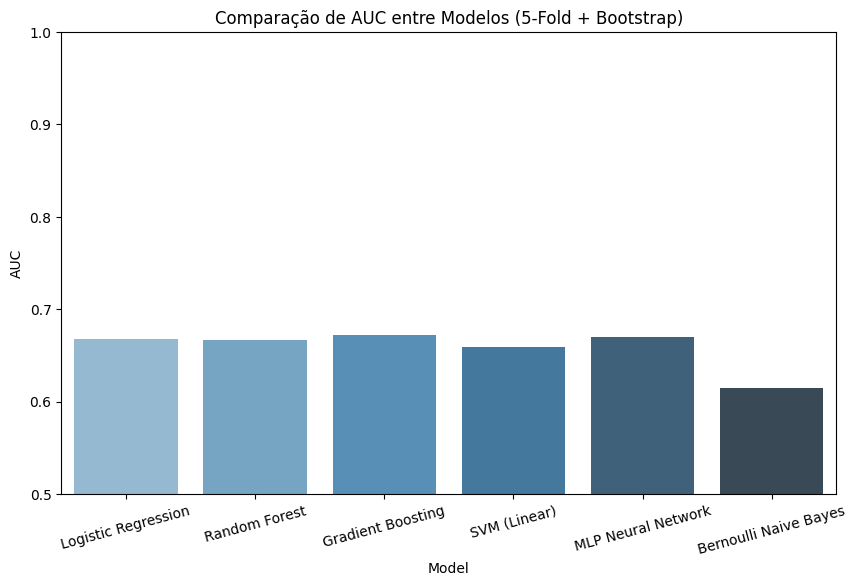

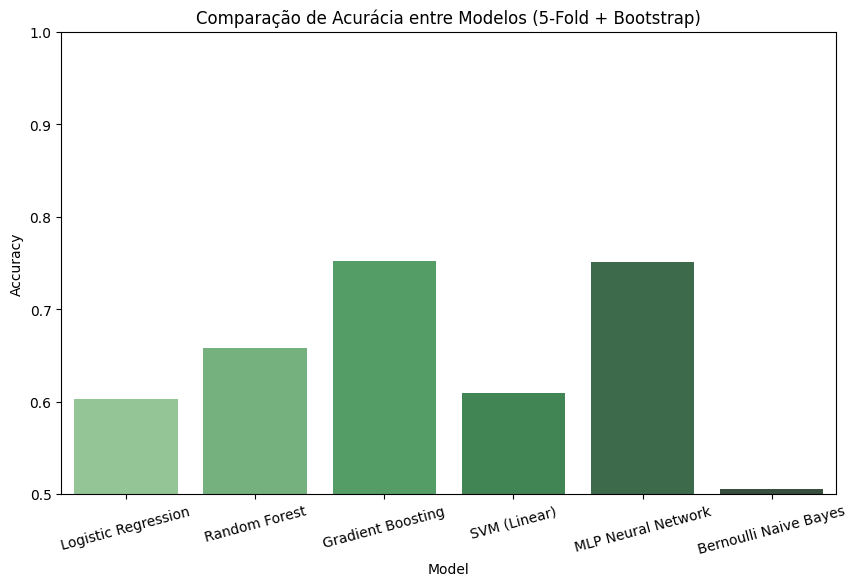

In [23]:
# ============================================
#   MÉDIAS POR MODELO
# ============================================

lr_mean  = np.mean(lr_metrics, axis=0)
rf_mean  = np.mean(rf_metrics, axis=0)
gb_mean  = np.mean(gb_metrics, axis=0)
svm_mean = np.mean(svm_metrics, axis=0)
mlp_mean = np.mean(mlp_metrics, axis=0)
bnb_mean = np.mean(bnb_metrics, axis=0)

# ============================================
#   TABELA FINAL COM TODOS OS MODELOS
# ============================================

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVM (Linear)",
        "MLP Neural Network",
        "Bernoulli Naive Bayes"
    ],

    "Accuracy": [
        lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0],
        mlp_mean[0], bnb_mean[0]
    ],

    "Sensitivity": [
        lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1],
        mlp_mean[1], bnb_mean[1]
    ],

    "Specificity": [
        lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2],
        mlp_mean[2], bnb_mean[2]
    ],

    "PPV": [
        lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7],
        mlp_mean[7], bnb_mean[7]
    ],

    "NPV": [
        lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8],
        mlp_mean[8], bnb_mean[8]
    ],

    "AUC": [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc),
        np.mean(mlp_auc),
        np.mean(bnb_auc)
    ]
})

print("📊 Resultados Médios (5-Fold + Bootstrap 1000):")
display(results_df.round(3))


plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="AUC", data=results_df, palette="Blues_d")
plt.title("Comparação de AUC entre Modelos (5-Fold + Bootstrap)")
plt.ylim(0.5, 1)
plt.ylabel("AUC")
plt.xticks(rotation=15)
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="Greens_d")
plt.title("Comparação de Acurácia entre Modelos (5-Fold + Bootstrap)")
plt.ylim(0.5, 1)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


Top 15 variáveis mais importantes — Gradient Boosting:



,Importância
RIGDNECK,0.0913
DATSCAN,0.0589
FACEXP,0.0578
PARKAGE,0.0575
MOMOPARK,0.0572
BRADYKIN,0.0513
PDOTHR,0.0500
ARISING,0.0338
PARK,0.0324
POSTURE,0.0318


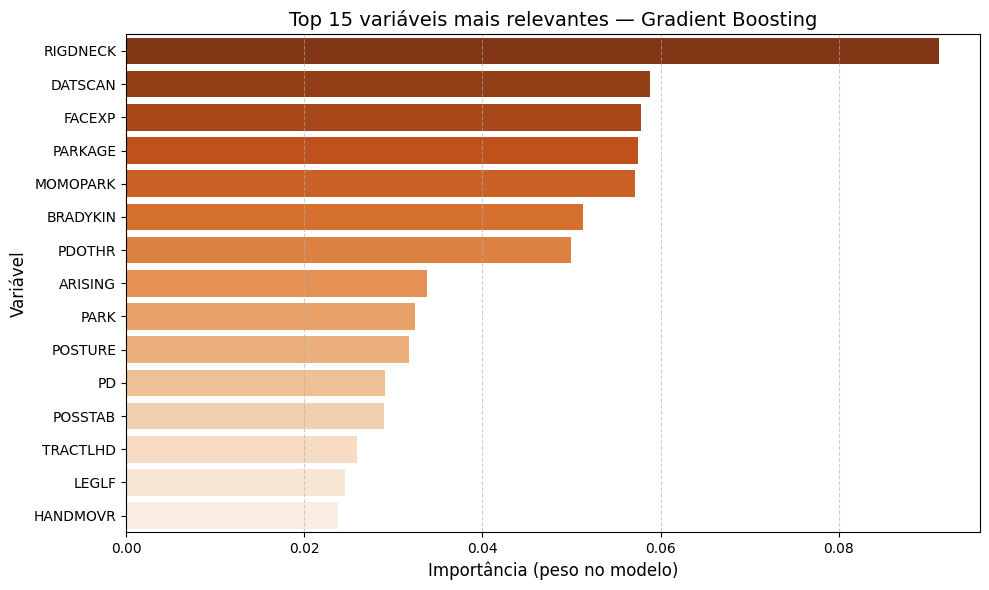

In [24]:

gb_best = gb_models[0]

feat_gb = pd.Series(
    gb_best.feature_importances_,
    index=X.columns[:len(gb_best.feature_importances_)]
)

top15_gb = feat_gb.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — Gradient Boosting:\n")
display(top15_gb.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_gb.values, y=top15_gb.index, palette="Oranges_r")
plt.title("Top 15 variáveis mais relevantes — Gradient Boosting", fontsize=14)
plt.xlabel("Importância (peso no modelo)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — SVM (Fold 1):



,Importância
GAIT,3.1735
TRACTLHD,2.4224
DATSCAN,2.2820
FACEXP,2.1968
BRADYKIN,2.1447
PD,1.6939
NACCLBDE,1.3535
LEGLF,1.3487
LBDEVAL,1.3091
ARISING,1.3090


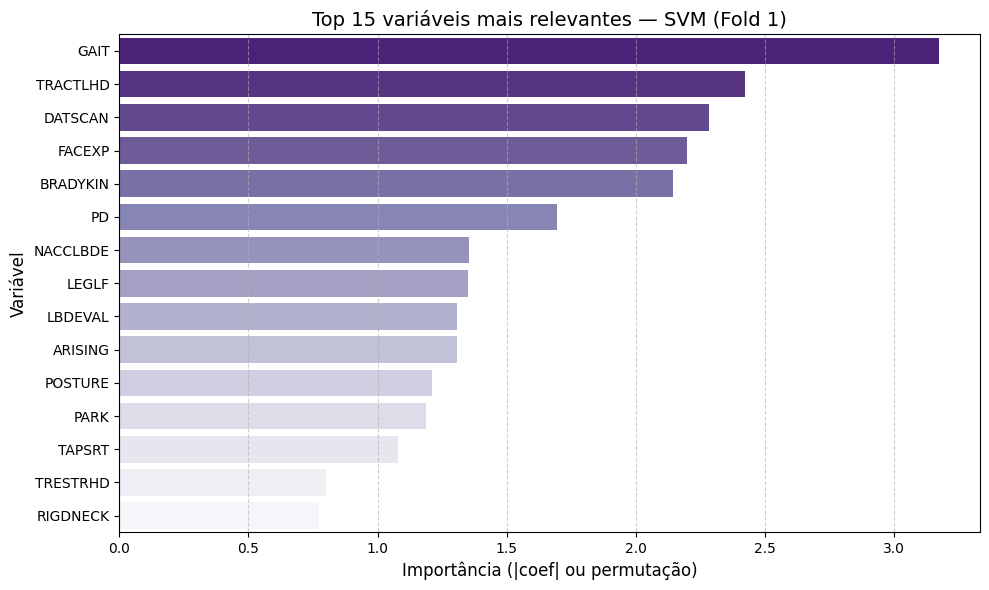

In [25]:

from sklearn.inspection import permutation_importance

svm_best = svm_models[0]

if hasattr(svm_best, "kernel") and svm_best.kernel == "linear":
    feat_svm = pd.Series(
        np.abs(svm_best.coef_[0]),
        index=X.columns[:len(svm_best.coef_[0])]
    )
else:
    print("SVM com kernel não linear — usando permutation importance...")
    perm = permutation_importance(svm_best, X_final, y_array, n_repeats=10, random_state=42, n_jobs=-1)
    feat_svm = pd.Series(perm.importances_mean, index=X.columns)

top15_svm = feat_svm.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — SVM (Fold 1):\n")
display(top15_svm.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_svm.values, y=top15_svm.index, palette="Purples_r")
plt.title("Top 15 variáveis mais relevantes — SVM (Fold 1)", fontsize=14)
plt.xlabel("Importância (|coef| ou permutação)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


🏆 Top 15 variáveis mais importantes — Logistic Regression (Fold 1):



,Peso |coef|
TRACTLHD,1.5129
DATSCAN,1.4727
GAIT,1.3448
FACEXP,1.2167
BRADYKIN,1.1703
PD,1.0951
LEGLF,1.0558
LBDEVAL,1.0140
ARISING,1.0076
PARKAGE,0.9958


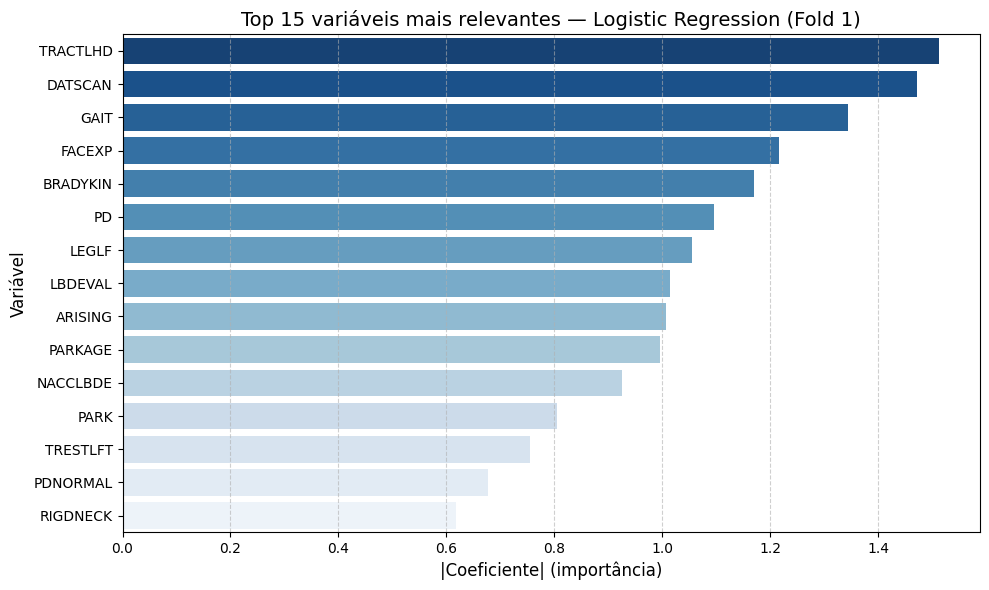

In [26]:


lr_best = lr_models[0]

coefs = pd.Series(
    np.abs(lr_best.coef_[0]),
    index=X.columns[:len(lr_best.coef_[0])]
)

top15_lr = coefs.sort_values(ascending=False).head(15)

print("🏆 Top 15 variáveis mais importantes — Logistic Regression (Fold 1):\n")
display(top15_lr.round(4).to_frame("Peso |coef|"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_lr.values, y=top15_lr.index, palette="Blues_r")
plt.title("Top 15 variáveis mais relevantes — Logistic Regression (Fold 1)", fontsize=14)
plt.xlabel("|Coeficiente| (importância)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — Random Forest (Fold 1):



,Importância
PARKAGE,0.1281
RIGDNECK,0.0834
PDOTHR,0.0720
FACEXP,0.0656
MOMOPARK,0.0625
DATSCAN,0.0381
BRADYKIN,0.0351
PARK,0.0293
PD,0.0289
POSTURE,0.0280


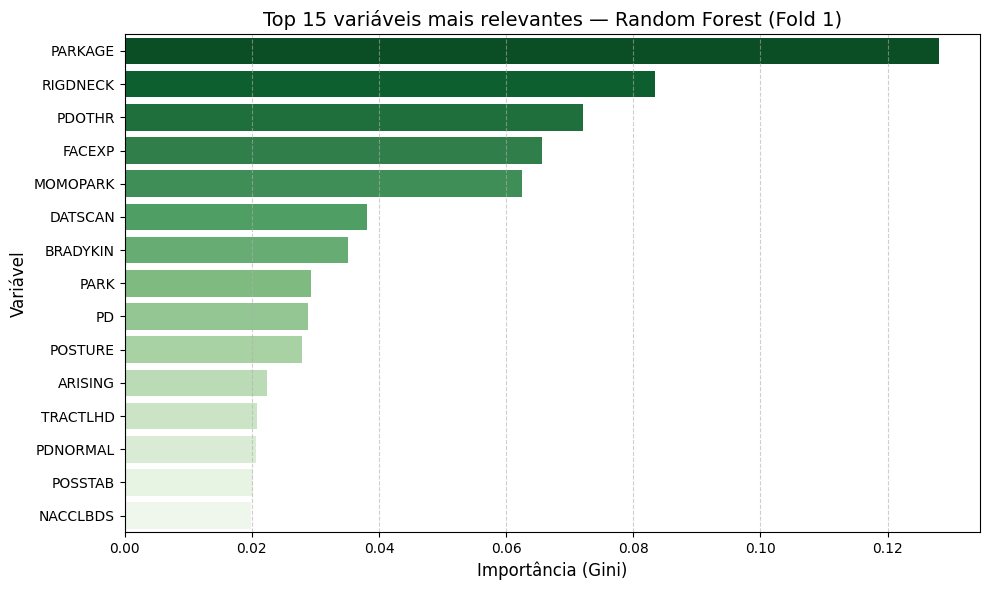

In [27]:

rf_best = rf_models[0]

feat_rf = pd.Series(
    rf_best.feature_importances_,
    index=X.columns[:len(rf_best.feature_importances_)]
)

top15_rf = feat_rf.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — Random Forest (Fold 1):\n")
display(top15_rf.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_rf.values, y=top15_rf.index, palette="Greens_r")
plt.title("Top 15 variáveis mais relevantes — Random Forest (Fold 1)", fontsize=14)
plt.xlabel("Importância (Gini)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — BernoulliNB:



,Importância
PDOTHRYR,0.0270
NACCPDMD,0.0000
MOMOPARK,0.0000
PARKGAIT,0.0000
PARK,0.0000
PDOTHR,0.0000
DATSCAN,0.0000
PARKAGE,0.0000
PARKSIGN,0.0000
PD,0.0000


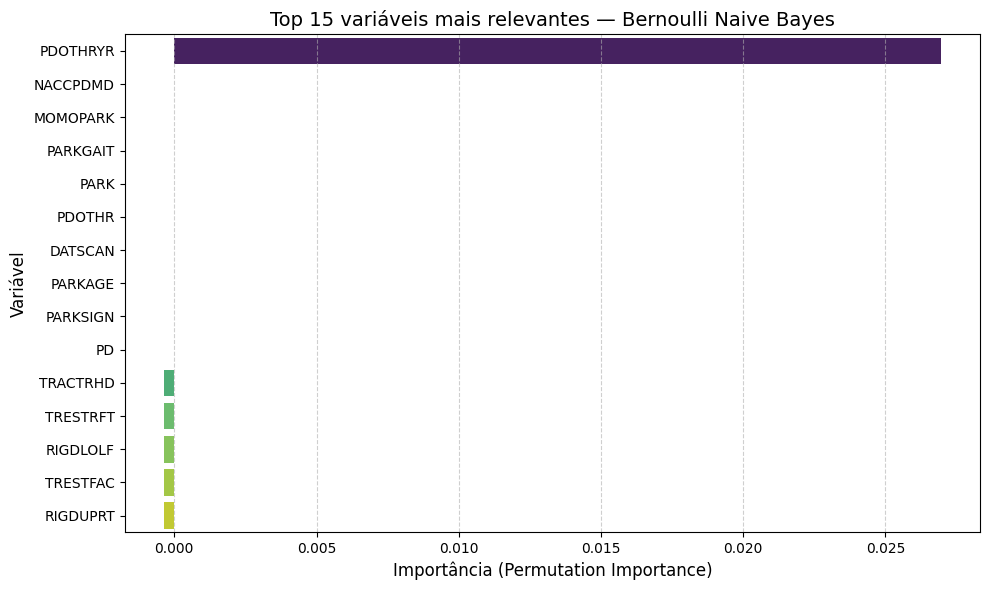

In [28]:
# ================================
#     TOP 15 — BernoulliNB
# ================================

# =============== BernoulliNB ===============

bnb_first = bnb_feat[0]   # importância do fold 1
feat_bnb = pd.Series(
    bnb_first,
    index=final_colnames[:len(bnb_first)]
)

top15_bnb = feat_bnb.sort_values(ascending=False).head(15)


print("Top 15 variáveis mais importantes — BernoulliNB:\n")
display(top15_bnb.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_bnb.values, y=top15_bnb.index, palette="viridis")
plt.title("Top 15 variáveis mais relevantes — Bernoulli Naive Bayes", fontsize=14)
plt.xlabel("Importância (Permutation Importance)", fontsize=12)
plt.ylabel("Variável", fontsize=12) 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — MLP (Permutation Importance):



,Importância
PARKAGE,0.0878
MOMOPARK,0.0241
POSTURE,0.0214
PDOTHRYR,0.0176
PDNORMAL,0.0157
TRACTLHD,0.0150
PARKSIGN,0.0135
ARISING,0.0077
FACEXP,0.0069
BRADYKIN,0.0063


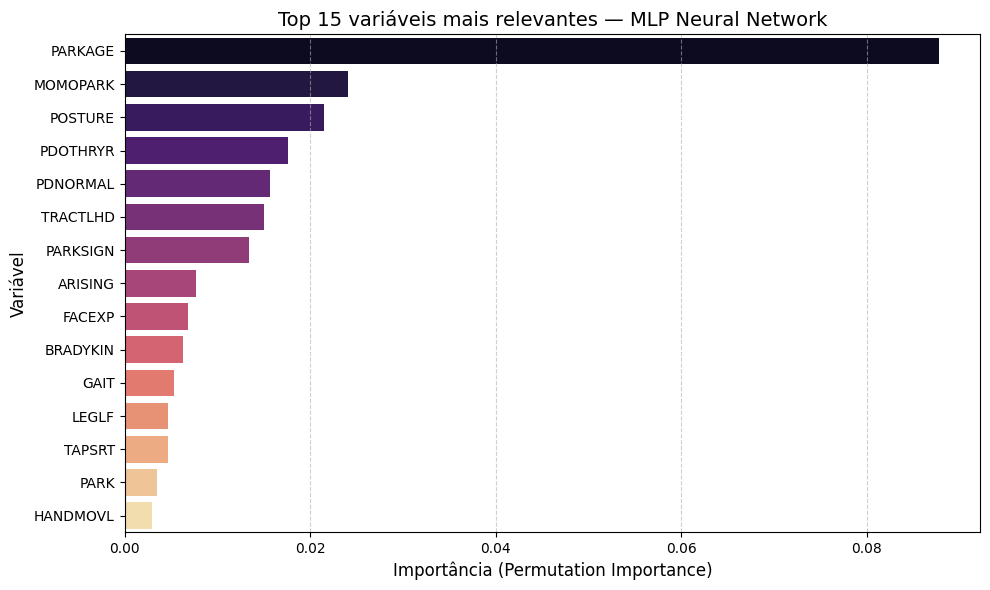

In [29]:
# ================================
#     TOP 15 — MLP
# ================================
# =============== MLP ===============

mlp_first = mlp_feat[0]   # importância do fold 1
feat_mlp = pd.Series(
    mlp_first,
    index=final_colnames[:len(mlp_first)]
)

top15_mlp = feat_mlp.sort_values(ascending=False).head(15)


print("Top 15 variáveis mais importantes — MLP (Permutation Importance):\n")
display(top15_mlp.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_mlp.values, y=top15_mlp.index, palette="magma")
plt.title("Top 15 variáveis mais relevantes — MLP Neural Network", fontsize=14)
plt.xlabel("Importância (Permutation Importance)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Tabela comparativa — Top 15 variáveis por modelo:



,Logistic Regression,Random Forest,Gradient Boosting,SVM (Linear),MLP Neural Network,Bernoulli Naive Bayes
0,TRACTLHD,PARKAGE,RIGDNECK,GAIT,PARKAGE,PDOTHRYR
1,DATSCAN,RIGDNECK,DATSCAN,TRACTLHD,MOMOPARK,NACCPDMD
2,GAIT,PDOTHR,FACEXP,DATSCAN,POSTURE,MOMOPARK
3,FACEXP,FACEXP,PARKAGE,FACEXP,PDOTHRYR,PARKGAIT
4,BRADYKIN,MOMOPARK,MOMOPARK,BRADYKIN,PDNORMAL,PARK
5,PD,DATSCAN,BRADYKIN,PD,TRACTLHD,PDOTHR
6,LEGLF,BRADYKIN,PDOTHR,NACCLBDE,PARKSIGN,DATSCAN
7,LBDEVAL,PARK,ARISING,LEGLF,ARISING,PARKAGE
8,ARISING,PD,PARK,LBDEVAL,FACEXP,PARKSIGN
9,PARKAGE,POSTURE,POSTURE,ARISING,BRADYKIN,PD



Variáveis mais recorrentes entre modelos:



,Variável,Frequência
0,PARK,6
2,FACEXP,5
3,BRADYKIN,5
4,PD,5
5,DATSCAN,5
6,ARISING,5
7,PARKAGE,5
1,TRACTLHD,5
10,MOMOPARK,4
11,LEGLF,4


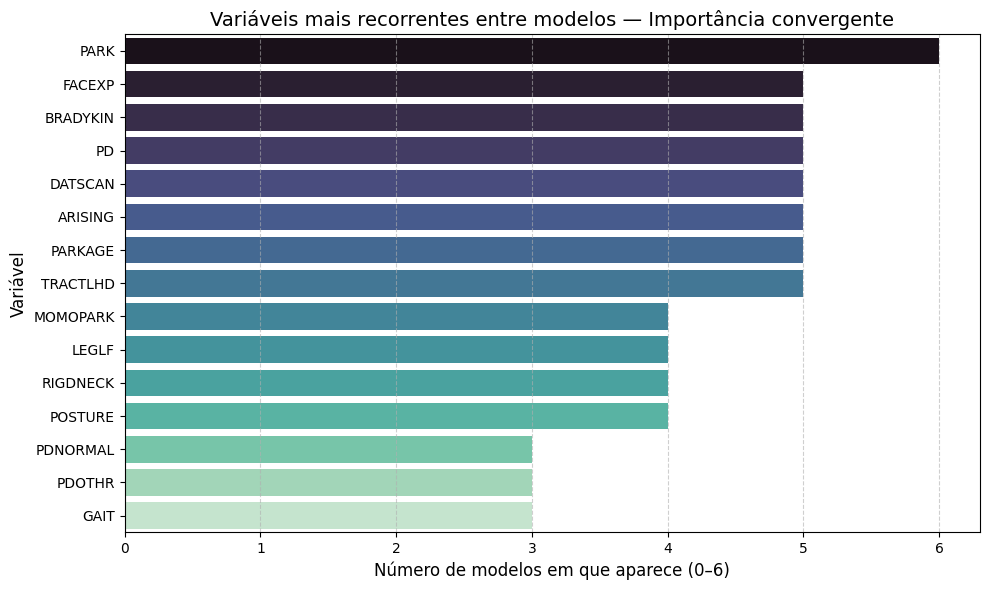

In [30]:
# ============================================================
#   Tabela comparativa dos Top 15 entre TODOS os modelos
# ============================================================

top_features_dict = {
    "Logistic Regression": list(top15_lr.index),
    "Random Forest": list(top15_rf.index),
    "Gradient Boosting": list(top15_gb.index),
    "SVM (Linear)": list(top15_svm.index),
    "MLP Neural Network": list(top15_mlp.index),
    "Bernoulli Naive Bayes": list(top15_bnb.index)
}

# Converter para DataFrame (coluna = modelo, linhas = variáveis top 15)
df_top_features = pd.DataFrame({model: pd.Series(vars_) 
                                for model, vars_ in top_features_dict.items()})

print("Tabela comparativa — Top 15 variáveis por modelo:\n")
display(df_top_features)

# ============================================================
#   Frequência das variáveis mais recorrentes 
# ============================================================

# Junta todas as variáveis dos 6 modelos em uma única lista
all_features = sum(top_features_dict.values(), [])

# Conta quantas vezes cada variável aparece
feature_counts = pd.Series(all_features).value_counts()

freq_df = feature_counts.reset_index()
freq_df.columns = ["Variável", "Frequência"]
freq_df = freq_df.sort_values(by="Frequência", ascending=False)

print("\nVariáveis mais recorrentes entre modelos:\n")
display(freq_df.head(15))

# ============================================================
#   Gráfico das variáveis mais recorrentes
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(x="Frequência", y="Variável", data=freq_df.head(15), palette="mako")

plt.title("Variáveis mais recorrentes entre modelos — Importância convergente", fontsize=14)
plt.xlabel("Número de modelos em que aparece (0–6)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Tabela 3 — Comparação dos modelos (5-Fold + Bootstrap 1000):


,Modelo,Accuracy,Sensitivity (Recall),Specificity,PPV,NPV,AUC
0,Logistic Regression,0.603,0.631,0.594,0.335,0.833,0.668
1,Random Forest,0.658,0.507,0.706,0.361,0.816,0.666
2,Gradient Boosting,0.752,0.117,0.958,0.488,0.770,0.672
3,SVM (Linear),0.609,0.598,0.613,0.334,0.825,0.659
4,MLP Neural Network,0.750,0.093,0.964,0.436,0.766,0.670
5,Bernoulli Naive Bayes,0.505,0.734,0.431,0.295,0.835,0.614


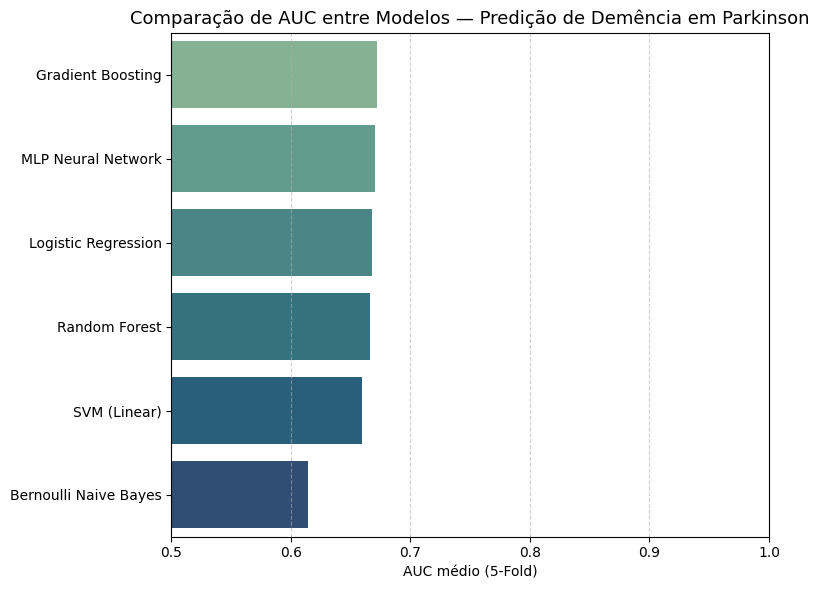

In [31]:
# ============================================
#   MÉDIAS POR MODELO (5-Fold + Bootstrap)
# ============================================

lr_mean  = np.mean(lr_metrics, axis=0)
rf_mean  = np.mean(rf_metrics, axis=0)
gb_mean  = np.mean(gb_metrics, axis=0)
svm_mean = np.mean(svm_metrics, axis=0)
mlp_mean = np.mean(mlp_metrics, axis=0)
bnb_mean = np.mean(bnb_metrics, axis=0)

# ============================================
#   Tabela 3 — Comparação entre TODOS os modelos
# ============================================

results_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'SVM (Linear)',
        'MLP Neural Network',
        'Bernoulli Naive Bayes'
    ],

    'Accuracy': [
        lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0],
        mlp_mean[0], bnb_mean[0]
    ],

    'Sensitivity (Recall)': [
        lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1],
        mlp_mean[1], bnb_mean[1]
    ],

    'Specificity': [
        lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2],
        mlp_mean[2], bnb_mean[2]
    ],

    'PPV': [
        lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7],
        mlp_mean[7], bnb_mean[7]
    ],

    'NPV': [
        lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8],
        mlp_mean[8], bnb_mean[8]
    ],

    'AUC': [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc),
        np.mean(mlp_auc),
        np.mean(bnb_auc)
    ]
})

print("Tabela 3 — Comparação dos modelos (5-Fold + Bootstrap 1000):")
display(results_df.round(3))

# ============================================
#   Gráfico atualizado — AUC
# ============================================

plt.figure(figsize=(8, 6))
sns.barplot(x='AUC', y='Modelo', data=results_df.sort_values('AUC', ascending=False), palette='crest')

plt.title('Comparação de AUC entre Modelos — Predição de Demência em Parkinson', fontsize=13)
plt.xlabel('AUC médio (5-Fold)')
plt.ylabel('')
plt.xlim(0.5, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


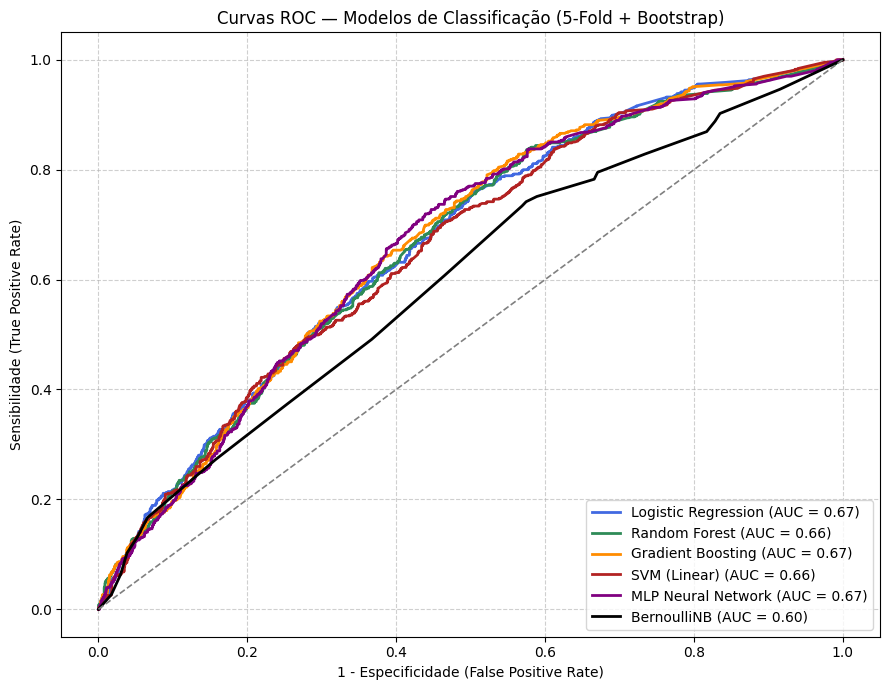

In [32]:
plt.figure(figsize=(9, 7))

# =======================
# Logistic Regression
# =======================
fpr_lr, tpr_lr, _ = roc_curve(lr_true, lr_probs)
auc_lr = roc_auc_score(lr_true, lr_probs)
plt.plot(fpr_lr, tpr_lr, lw=2, color="royalblue",
         label=f"Logistic Regression (AUC = {auc_lr:.2f})")

# =======================
# Random Forest
# =======================
fpr_rf, tpr_rf, _ = roc_curve(rf_true, rf_probs)
auc_rf = roc_auc_score(rf_true, rf_probs)
plt.plot(fpr_rf, tpr_rf, lw=2, color="seagreen",
         label=f"Random Forest (AUC = {auc_rf:.2f})")

# =======================
# Gradient Boosting
# =======================
fpr_gb, tpr_gb, _ = roc_curve(gb_true, gb_probs)
auc_gb = roc_auc_score(gb_true, gb_probs)
plt.plot(fpr_gb, tpr_gb, lw=2, color="darkorange",
         label=f"Gradient Boosting (AUC = {auc_gb:.2f})")

# =======================
# SVM Linear
# =======================
fpr_svm, tpr_svm, _ = roc_curve(svm_true, svm_probs)
auc_svm = roc_auc_score(svm_true, svm_probs)
plt.plot(fpr_svm, tpr_svm, lw=2, color="firebrick",
         label=f"SVM (Linear) (AUC = {auc_svm:.2f})")

# =======================
# MLP Neural Network
# =======================
fpr_mlp, tpr_mlp, _ = roc_curve(mlp_true, mlp_probs)
auc_mlp = roc_auc_score(mlp_true, mlp_probs)
plt.plot(fpr_mlp, tpr_mlp, lw=2, color="purple",
         label=f"MLP Neural Network (AUC = {auc_mlp:.2f})")

# =======================
# Bernoulli Naive Bayes
# =======================
fpr_bnb, tpr_bnb, _ = roc_curve(bnb_true, bnb_probs)
auc_bnb = roc_auc_score(bnb_true, bnb_probs)
plt.plot(fpr_bnb, tpr_bnb, lw=2, color="black",
         label=f"BernoulliNB (AUC = {auc_bnb:.2f})")

# =======================
# Diagonal de referência
# =======================
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.2)

# =======================
# Layout
# =======================
plt.xlabel("1 - Especificidade (False Positive Rate)")
plt.ylabel("Sensibilidade (True Positive Rate)")
plt.title("Curvas ROC — Modelos de Classificação (5-Fold + Bootstrap)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [33]:
resultados_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'SVM (Linear)',
        'MLP Neural Network',
        'Bernoulli Naive Bayes'
    ],
    
    'Accuracy': [
        lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0],
        mlp_mean[0], bnb_mean[0]
    ],
    
    'Sensibilidade': [
        lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1],
        mlp_mean[1], bnb_mean[1]
    ],
    
    'Especificidade': [
        lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2],
        mlp_mean[2], bnb_mean[2]
    ],
    
    'PPV': [
        lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7],
        mlp_mean[7], bnb_mean[7]
    ],
    
    'NPV': [
        lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8],
        mlp_mean[8], bnb_mean[8]
    ],
    
    'AUC': [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc),
        np.mean(mlp_auc),
        np.mean(bnb_auc)
    ]
})

display(resultados_df.round(3))


,Modelo,Accuracy,Sensibilidade,Especificidade,PPV,NPV,AUC
0,Logistic Regression,0.603,0.631,0.594,0.335,0.833,0.668
1,Random Forest,0.658,0.507,0.706,0.361,0.816,0.666
2,Gradient Boosting,0.752,0.117,0.958,0.488,0.770,0.672
3,SVM (Linear),0.609,0.598,0.613,0.334,0.825,0.659
4,MLP Neural Network,0.750,0.093,0.964,0.436,0.766,0.670
5,Bernoulli Naive Bayes,0.505,0.734,0.431,0.295,0.835,0.614


In [34]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


Resultados Médios — 5-Fold + Bootstrap (Tabela 3):


,Modelo,AUC,Accuracy,Sensibilidade,Especificidade,PPV,NPV
0,Logistic Regression,0.668,0.603,0.631,0.594,0.335,0.833
1,Random Forest,0.666,0.658,0.507,0.706,0.361,0.816
2,Gradient Boosting,0.672,0.752,0.117,0.958,0.488,0.770
3,SVM (Linear),0.659,0.609,0.598,0.613,0.334,0.825
4,MLP Neural Network,0.670,0.750,0.093,0.964,0.436,0.766
5,Bernoulli Naive Bayes,0.614,0.505,0.734,0.431,0.295,0.835


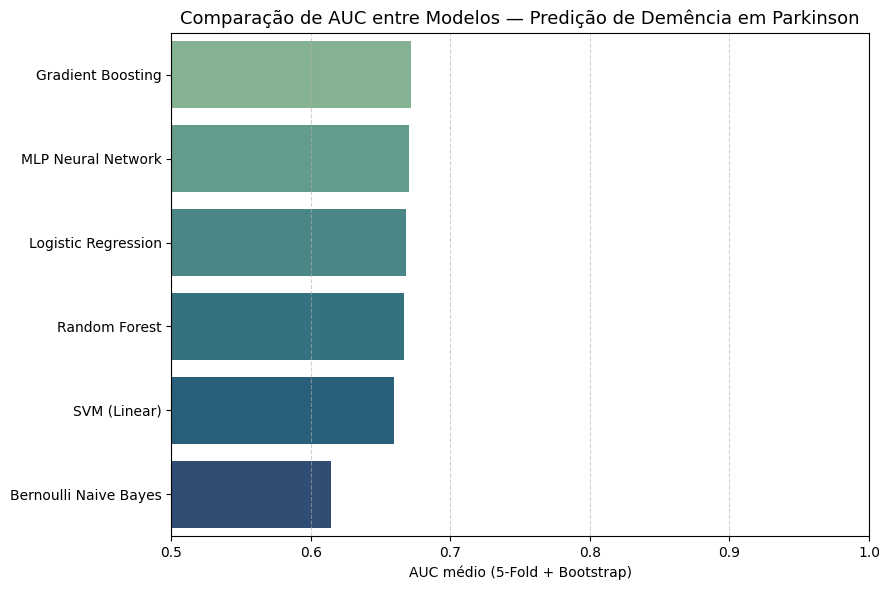

Tabela 3 exportada para 'results/Tabela3_Modelos_Parkinson.xlsx' com sucesso.


In [35]:
metric_names = [
    'accuracy', 'sensitivity', 'specificity', 'positive_likelihood',
    'negative_likelihood', 'false_positive_rate', 'false_negative_rate',
    'ppv', 'npv', 'positive_rate'
]

# Médias das métricas por modelo
lr_mean  = pd.Series(np.mean(lr_metrics, axis=0), index=metric_names)
rf_mean  = pd.Series(np.mean(rf_metrics, axis=0), index=metric_names)
gb_mean  = pd.Series(np.mean(gb_metrics, axis=0), index=metric_names)
svm_mean = pd.Series(np.mean(svm_metrics, axis=0), index=metric_names)
mlp_mean = pd.Series(np.mean(mlp_metrics, axis=0), index=metric_names)
bnb_mean = pd.Series(np.mean(bnb_metrics, axis=0), index=metric_names)

# ================================
#   Tabela final com 6 modelos
# ================================
results_df = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVM (Linear)",
        "MLP Neural Network",
        "Bernoulli Naive Bayes"
    ],

    "AUC": [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc),
        np.mean(mlp_auc),
        np.mean(bnb_auc)
    ],

    "Accuracy": [
        lr_mean['accuracy'], rf_mean['accuracy'], gb_mean['accuracy'],
        svm_mean['accuracy'], mlp_mean['accuracy'], bnb_mean['accuracy']
    ],

    "Sensibilidade": [
        lr_mean['sensitivity'], rf_mean['sensitivity'], gb_mean['sensitivity'],
        svm_mean['sensitivity'], mlp_mean['sensitivity'], bnb_mean['sensitivity']
    ],

    "Especificidade": [
        lr_mean['specificity'], rf_mean['specificity'], gb_mean['specificity'],
        svm_mean['specificity'], mlp_mean['specificity'], bnb_mean['specificity']
    ],

    "PPV": [
        lr_mean['ppv'], rf_mean['ppv'], gb_mean['ppv'],
        svm_mean['ppv'], mlp_mean['ppv'], bnb_mean['ppv']
    ],

    "NPV": [
        lr_mean['npv'], rf_mean['npv'], gb_mean['npv'],
        svm_mean['npv'], mlp_mean['npv'], bnb_mean['npv']
    ]
})

print("Resultados Médios — 5-Fold + Bootstrap (Tabela 3):")
display(results_df.round(3))

# ================================
#   Gráfico de AUC atualizado
# ================================
plt.figure(figsize=(9, 6))
sns.barplot(
    x="AUC",
    y="Modelo",
    data=results_df.sort_values("AUC", ascending=False),
    palette="crest"
)

plt.title("Comparação de AUC entre Modelos — Predição de Demência em Parkinson", fontsize=13)
plt.xlabel("AUC médio (5-Fold + Bootstrap)")
plt.ylabel("")
plt.xlim(0.5, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ================================
#   Exportação para Excel
# ================================
output_path = "results/Tabela3_Modelos_Parkinson.xlsx"
os.makedirs("results", exist_ok=True)
results_df.round(4).to_excel(output_path, index=False)

print(f"Tabela 3 exportada para '{output_path}' com sucesso.")
